In [1]:
#importing require python classes and packages
from pyspark.sql import SQLContext
from pyspark.sql import SparkSession
from pyspark import SparkConf, SparkContext
from FuzzyBayesianImputer import FuzzyBayesianImputer #loading fuzzy imputer class
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
import math
from FormerAttention import FormerAttention
from keras.models import Sequential, load_model
from keras.layers import Dense, Activation
from keras.layers import Dropout, LSTM, RepeatVector, Flatten, Bidirectional, GRU
from keras.callbacks import ModelCheckpoint
import os
import pickle
from sklearn.model_selection import train_test_split
from keras.layers import MaxPooling2D
from keras.layers import Convolution2D
import matplotlib.pyplot as plt

Using TensorFlow backend.
c:\users\harsh\appdata\local\programs\python\python37\lib\site-packages\tensorflow\python\framework\dtypes.py:516: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
c:\users\harsh\appdata\local\programs\python\python37\lib\site-packages\tensorflow\python\framework\dtypes.py:517: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
c:\users\harsh\appdata\local\programs\python\python37\lib\site-packages\tensorflow\python\framework\dtypes.py:518: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16

In [2]:
#defining spark object
spark = SparkSession.builder.appName("HDFS").getOrCreate()
sparkcont = SparkContext.getOrCreate(SparkConf().setAppName("HDFS"))
logs = sparkcont.setLogLevel("ERROR")
print("Spark Context Initialized")

Spark Context Initialized


In [3]:
#now load & display earthquake dataset using apache spark 
df = spark.read.csv('Dataset/AgricultureData.csv', inferSchema=True, header=True)
df.show()#displaying first 20 rows from loaded dataset

+-----------+-----------+------------------+------------------+------------------+------------------+
|temperature|   humidity|       crop_growth|luminous_intensity| co2_concentration|   total_radiation|
+-----------+-----------+------------------+------------------+------------------+------------------+
|20.87974371|82.00274423| 29.44606392482905|  8.67735526697563|  435.611225664072|188.19495775411988|
|21.77046169|80.31964408|12.851182636936995| 5.754287955222303|401.45185974634256| 70.96362942364794|
|23.00445915| 82.3207629|29.363912891054824| 9.875230096038331| 357.4179627074981|191.97607728111197|
|26.49109635|80.15836264| 26.20773239299878| 8.023684684293785| 363.6943055002588| 55.76138848397649|
|20.13017482|81.60487287|28.236236135835615|  8.12051188272924|410.35645777701023|185.25970154082896|
|23.05804872|83.37011772| 23.61311519614218|10.873767569219408| 428.7284296936261|135.92906584189868|
|22.70883798|82.63941394|15.333693105308976| 8.726839860577611| 398.3170075705707|

In [4]:
#function to calculate RSE metric
def RSE(y_true, y_pred):
    # Calculate the sum of squared errors
    sum_squared_errors = np.sum((y_true - y_pred)**2)
    # Calculate the sum of squared differences from the mean of true values
    sum_squared_total = np.sum((y_true - np.mean(y_true))**2)
    # Handle the case where sum_squared_total is zero to avoid division by zero
    if sum_squared_total == 0:
        return 0.0  # Or raise an error, depending on desired behavior
    rse = sum_squared_errors / sum_squared_total
    return rse

In [5]:
#check for missing values in dataset
dataset = df.toPandas()
dataset.isnull().sum()

temperature           22
humidity              14
crop_growth            0
luminous_intensity    17
co2_concentration     16
total_radiation       11
dtype: int64

In [6]:
#apply FuzzyBayesianImputer algorithm to construct complete dataset by removing missing values with fuzzy values
imputer = FuzzyBayesianImputer(alpha=1.5, n_iter=20)
imputed_data = imputer.fit_transform(dataset)
dataset = pd.DataFrame(imputed_data, columns=dataset.columns)
print("Dataset Missing Values Count after Fuzzy Imputation")
dataset.isnull().sum()

Dataset Missing Values Count after Fuzzy Imputation


temperature           0
humidity              0
crop_growth           0
luminous_intensity    0
co2_concentration     0
total_radiation       0
dtype: int64

In [7]:
#class to normalize dataset values
scaler = MinMaxScaler(feature_range = (0, 1))
scaler1 = MinMaxScaler(feature_range = (0, 1))

In [12]:
#apply dataset preprocessing such as X & Y features extraction & normalization
Y = dataset['crop_growth']
Y = Y.ravel()
dataset.drop(['crop_growth'], axis = 1,inplace=True)
X = dataset.values
Y = Y.reshape(-1, 1)
X = scaler.fit_transform(X)
Y = scaler1.fit_transform(Y)
print("Normalized Features = "+str(X))

Normalized Features = [[0.34588614 0.79026683 0.52596152 0.85624393 0.92129908]
 [0.37144489 0.77063285 0.10780289 0.51459221 0.13856806]
 [0.4068539  0.79397664 0.6973232  0.07417838 0.94654489]
 ...
 [0.43920235 0.61788046 0.87212923 0.10483002 0.24379956]
 [0.50062653 0.44175991 0.44298717 0.65524065 0.14676578]
 [0.42402921 0.53822177 0.5205807  0.63133061 0.83389488]]


In [14]:
#split processed features into train & test
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size = 0.2)
print("Dataset Size : "+str(X.shape[0]))
print("80% dataset size used for training : "+str(X_train.shape[0]))
print("20% dataset size used for testing  : "+str(X_test.shape[0]))
data = np.load("model/data.npy", allow_pickle=True)
X_train, X_test, y_train, y_test = data

Dataset Size : 2200
80% dataset size used for training : 1760
20% dataset size used for testing  : 440


In [22]:
#define global variables to save metrics
rmse = []
mae = []
rse = []

In [23]:
#function to calculate metrics using true and predicted crop growth
def calculateMetrics(algorithm, predict, test_labels):
    predict = predict.reshape(-1, 1)
    predict = scaler1.inverse_transform(predict)
    test_label = scaler1.inverse_transform(test_labels)
    predict = predict.ravel()
    test_label = test_label.ravel()
    rmse_error = math.sqrt(mean_squared_error(test_label, predict))
    mae_error = mean_absolute_error(test_label, predict)
    rse_error = RSE(test_label, predict)
    rmse.append(rmse_error)
    mae.append(mae_error)
    rse.append(rse_error)
    print(algorithm+" MAE : "+str(mae_error))
    print(algorithm+" RMSE : "+str(rmse_error))
    print(algorithm+" RSE : "+str(rse_error))
    print()
    for i in range(0, 10):
        print("True Growth : "+str(test_label[i])+" Predicted Growth : "+str(predict[i]))
    plt.figure(figsize=(5,3))
    plt.plot(test_label[0:100], color = 'red', label = 'True Growth')
    plt.plot(predict[0:100], color = 'green', label = 'Predicted Growth')
    plt.title(algorithm+' Work Load Prediction Graph')
    plt.xlabel('Test Data')
    plt.ylabel('Growth Prediction')
    plt.legend()
    plt.show()

LSTM MAE : 4.997517411918693
LSTM RMSE : 5.770099507430959
LSTM RSE : 0.998102991799761

True Growth : 26.40756000379458 Predicted Growth : 20.44762
True Growth : 11.107673771458952 Predicted Growth : 20.155025
True Growth : 15.532948055771904 Predicted Growth : 20.602638
True Growth : 16.15189052261151 Predicted Growth : 20.32585
True Growth : 29.363912891054827 Predicted Growth : 20.37197
True Growth : 27.22840461276248 Predicted Growth : 20.425304
True Growth : 10.308661233612549 Predicted Growth : 20.32975
True Growth : 17.777308012949078 Predicted Growth : 20.278597
True Growth : 25.940271838540543 Predicted Growth : 20.355686
True Growth : 20.505529046999705 Predicted Growth : 20.303175


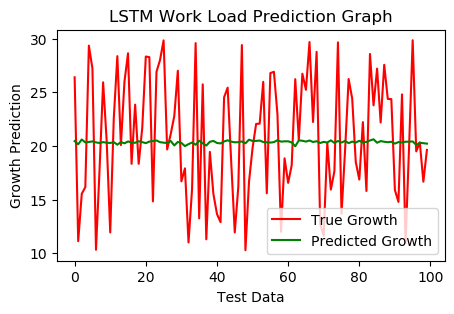

In [24]:
#convert training features as per LSTM format
X_train1 = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test1 = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))
#train existing LSTM algorithm
lstm_model = Sequential()#defining object
#adding lstm layer with 50 nuerons to filter dataset 50 time
lstm_model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train1.shape[1], X_train1.shape[2])))
#dropout layer to remove irrelevant features from dataset
lstm_model.add(Dropout(0.2))
lstm_model.add(LSTM(units=50, return_sequences=True))
lstm_model.add(Dropout(0.2))
lstm_model.add(LSTM(units=50))
lstm_model.add(Dropout(0.2))
lstm_model.add(Dense(units=1))#defining output crop yield prediction layer
lstm_model.compile(optimizer='adam', loss='mean_squared_error')
#now train and load the model
if os.path.exists("model/lstm_weights.hdf5") == False:
    model_check_point = ModelCheckpoint(filepath='model/lstm_weights.hdf5', verbose = 1, save_best_only = True)
    lstm_model.fit(X_train1, y_train, batch_size = 16, epochs = 1000, validation_data=(X_test1, y_test), callbacks=[model_check_point], verbose=1)
else:
    lstm_model.load_weights("model/lstm_weights.hdf5")
predict = lstm_model.predict(X_test1)
calculateMetrics("LSTM", predict, y_test)#call function to plot LSTM crop yield prediction

Propose FicFormer MAE : 3.0812710706619844
Propose FicFormer RMSE : 4.338637918276836
Propose FicFormer RSE : 0.564307168027281

True Growth : 26.40756000379458 Predicted Growth : 19.650957
True Growth : 11.107673771458952 Predicted Growth : 12.430643
True Growth : 15.532948055771904 Predicted Growth : 18.817986
True Growth : 16.15189052261151 Predicted Growth : 16.307571
True Growth : 29.363912891054827 Predicted Growth : 26.026184
True Growth : 27.22840461276248 Predicted Growth : 22.265968
True Growth : 10.308661233612549 Predicted Growth : 18.669804
True Growth : 17.777308012949078 Predicted Growth : 20.201471
True Growth : 25.940271838540543 Predicted Growth : 23.980001
True Growth : 20.505529046999705 Predicted Growth : 16.479263


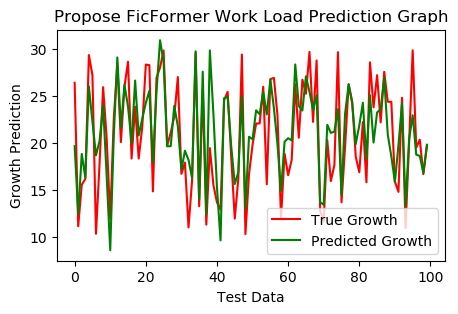

In [25]:
#convert training features as per FICformer format
X_train1 = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1, 1))
X_test1 = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1, 1))
#training FIC former encoder decoder model using attention
encoder = Sequential()
encoder.add(Convolution2D(32, (1, 1), input_shape = (X_train1.shape[1], X_train1.shape[2], X_train1.shape[3]), activation = 'relu'))
encoder.add(MaxPooling2D(pool_size = (1, 1)))
encoder.add(Convolution2D(32, (1, 1), activation = 'relu'))
encoder.add(MaxPooling2D(pool_size = (1, 1)))
encoder.add(Flatten())
encoder.add(RepeatVector(3))
encoder.add(FormerAttention(return_sequences=True,name='attention')) # define FICformer Attention layer
decoder = Dense(units = 256, activation = 'relu')
encoder.add(decoder)
encoder.add(Dense(units = 1))
encoder.compile(optimizer='adam', loss='mean_squared_error')
#now train and load the model
if os.path.exists("model/FicFormer.hdf5") == False:
    model_check_point = ModelCheckpoint(filepath='model/FicFormer.hdf5', verbose = 1, save_best_only = True)
    encoder.fit(X_train1, y_train, batch_size = 16, epochs = 1000, validation_data=(X_test1, y_test), callbacks=[model_check_point], verbose=1)
else:
    encoder = load_model("model/FicFormer.hdf5")
predict = encoder.predict(X_test1)
calculateMetrics("Propose FicFormer", predict, y_test)#call function to plot FICformer crop growth prediction

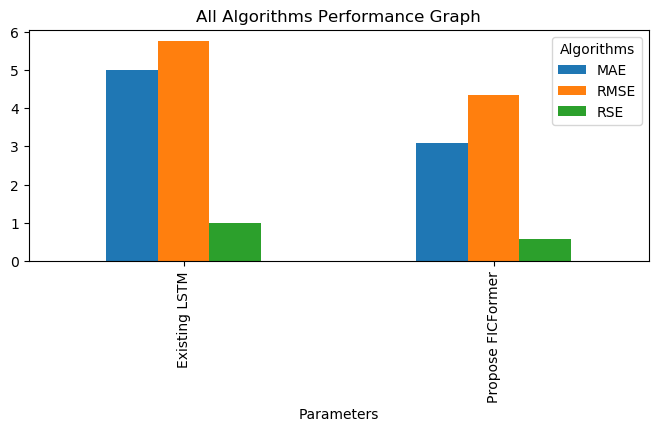

In [26]:
#plot all algorithm performance in tabular format
df = pd.DataFrame([['Existing LSTM','RMSE',rmse[0]],['Existing LSTM','MAE',mae[0]],['Existing LSTM','RSE',rse[0]],
                   ['Propose FICFormer','RMSE',rmse[1]],['Propose FICFormer','MAE',mae[1]],['Propose FICFormer','RSE',rse[1]],
                  ],columns=['Parameters','Algorithms','Value'])
df.pivot("Parameters", "Algorithms", "Value").plot(kind='bar', figsize=(8, 3))
plt.title("All Algorithms Performance Graph")
plt.show()

In [30]:
#display all algorithm performnace
algorithms = ['Existing LSTM', 'Propose FICFormer']
data = []
for i in range(len(rmse)):
    data.append([algorithms[i], rmse[i], mae[i], rse[i]])
data = pd.DataFrame(data, columns=['Algorithm Name', 'RMSE', 'MAE', 'RSE'])
data  

,Algorithm Name,RMSE,MAE,RSE
0,Existing LSTM,5.770100,4.997517,0.998103
1,Propose FICFormer,4.338638,3.081271,0.564307


In [32]:
#function to load test data and then predict crop growth based on humidity and temperature
testData = pd.read_csv("Dataset/testData.csv")
data = testData.values
testData = testData.values
testData = scaler.transform(testData)#normalized test data
testData = np.reshape(testData, (testData.shape[0], testData.shape[1], 1, 1))#resahpe test data
predict = encoder.predict(testData)#apply fic former encoder model to predict crop growth
predict = predict.reshape(-1, 1)
predict = scaler1.inverse_transform(predict)#convert predicted values to decimal crop growth
predict = predict.ravel()
for i in range(len(predict)):#loop and print predicted growth values
    print("Test Data = "+str(data[i])+" Predicted Crop Growth =====> "+str(predict[i]))
    print()

Test Data = [ 24.28209415  80.30025587  10.16869787 386.14283047 117.26676066] Predicted Crop Growth =====> 18.195353

Test Data = [ 21.58711777  82.7883708   10.74800154 435.48047518 182.0508468 ] Predicted Crop Growth =====> 20.103256

Test Data = [ 22.72791041  82.1706881    9.14361398 392.14531138  92.15260517] Predicted Crop Growth =====> 14.22465

Test Data = [ 24.87300744  82.84022551   9.98240186 352.60222029 108.03340693] Predicted Crop Growth =====> 24.147837

Test Data = [ 18.65054116  17.80852431  11.58089389 381.43197836 189.12405211] Predicted Crop Growth =====> 31.110067

Test Data = [ 17.48189735  18.8251973    9.76458572 366.03211745 133.62653435] Predicted Crop Growth =====> 17.949192

Test Data = [ 20.120043    22.89845607  11.13232667 449.17927632 138.30996178] Predicted Crop Growth =====> 16.515926

Test Data = [ 21.14011423  22.7182355   10.69769336 405.95540375  75.31009671] Predicted Crop Growth =====> 12.924719

